In [5]:
import os
import sys
from src.args.yaml_config import YamlConfig

yaml_config = YamlConfig().config

os.environ["KAGGLEHUB_CACHE"]="/sc/scratch/leon.hermann/kaggle"
sys.path.append("/sc/home/leon.hermann/birdclef-ml-framework")

In [2]:
# Read and show label file
import pandas as pd

file = yaml_config.base_data_dir + "/train_soundscapes_labels.csv"
labels = pd.read_csv(file)
labels.head()

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


In [3]:
from src.datasets.birdclef_dataset import LabelEncoder, BirdClefSample

label_encoder = LabelEncoder(taxonomy_file=yaml_config.base_data_dir + "/taxonomy.csv")

# Read each row and create a BirdClefSample
samples = []
for idx, (row_index, row) in enumerate(labels.iterrows()):
    if idx >= 5:
        break
    sample = BirdClefSample.from_soundscape_label(row, label_encoder, ds_path=yaml_config.base_data_dir + "/train_soundscapes")
    samples.append(sample)

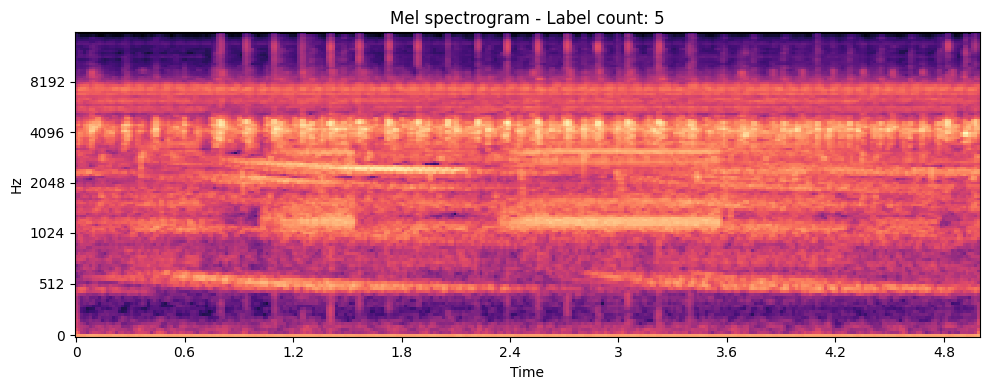

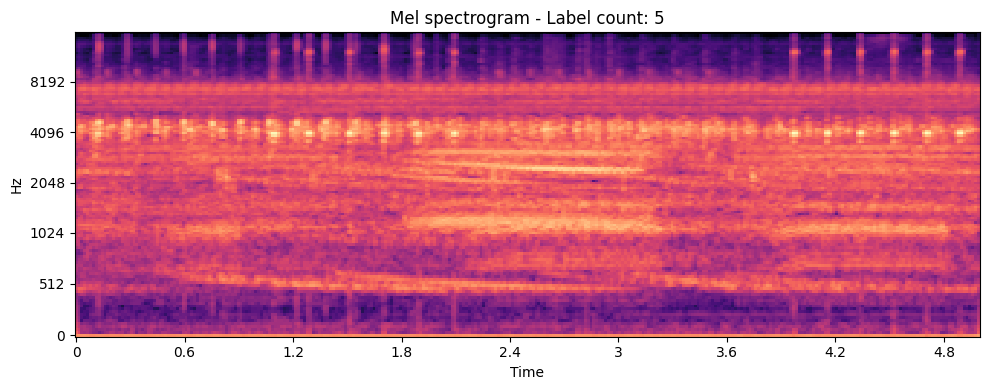

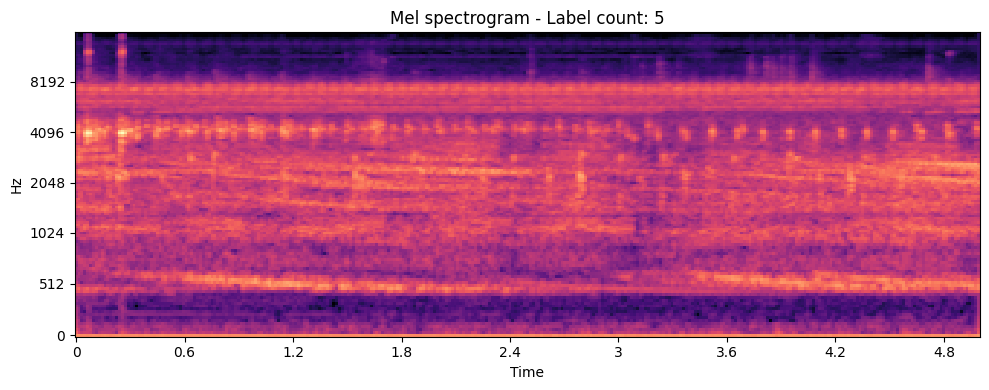

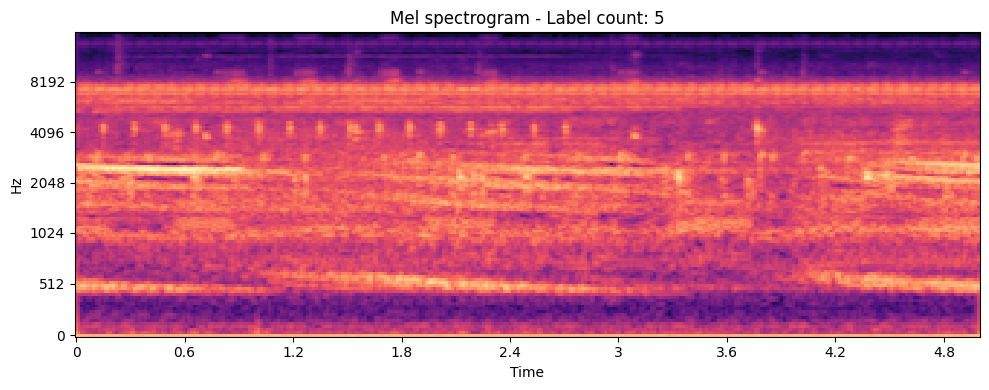

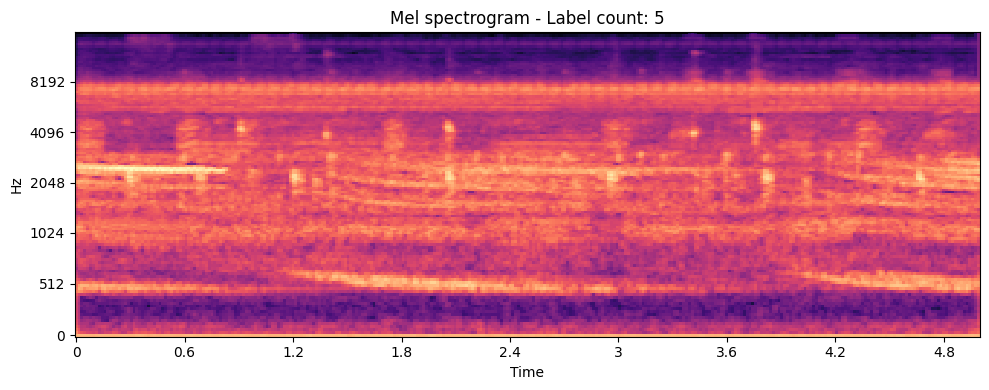

In [4]:
for sample in samples[:5]:
    sample.display()